# Análisis visual del dataset limpio

Gráficas de análisis sobre el dataset (`data/processed/airprice_clean.csv`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RUTA = "../data/processed/airprice_clean.csv"
df = pd.read_csv(RUTA)

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])
print("Faltantes:", df.isna().sum().sum())

Filas: 61617
Columnas: 32
Faltantes: 0


## 1. Análisis univariado del precio

Histograma + KDE y boxplot para observar la distribución de `price_clean` y detectar asimetría/outliers.

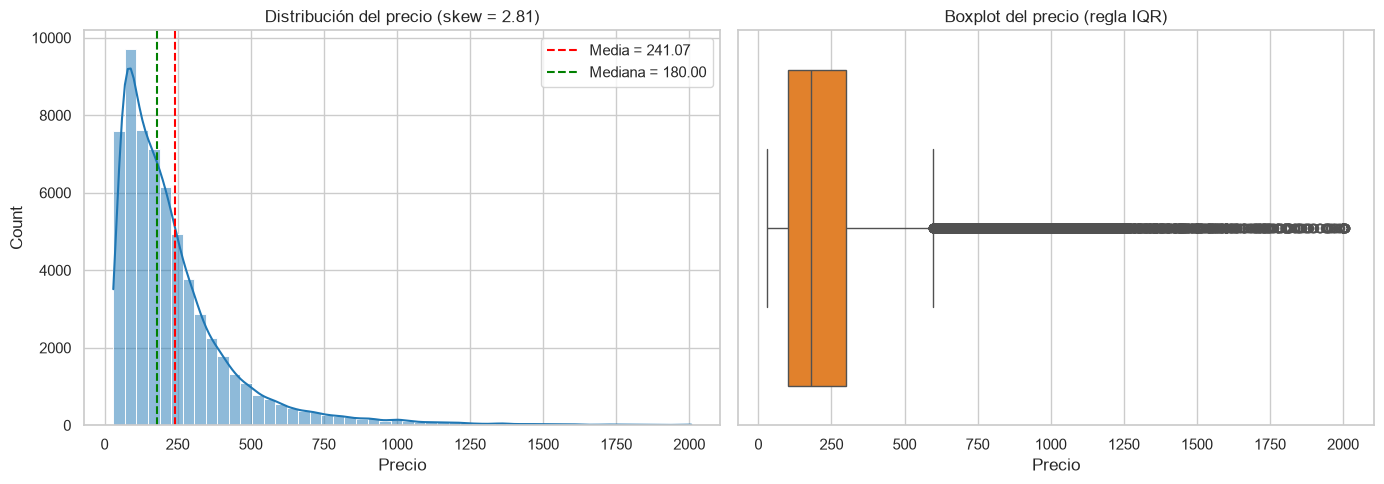

In [2]:
precio = df["price_clean"]
skew = precio.skew()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(precio, kde=True, bins=50, ax=axes[0], color="#1f77b4")
axes[0].axvline(precio.mean(), color="red", ls="--", label=f"Media = {precio.mean():.2f}")
axes[0].axvline(precio.median(), color="green", ls="--", label=f"Mediana = {precio.median():.2f}")
axes[0].set_title(f"Distribución del precio (skew = {skew:.2f})")
axes[0].set_xlabel("Precio")
axes[0].legend()

sns.boxplot(x=precio, ax=axes[1], color="#ff7f0e")
axes[1].set_title("Boxplot del precio (regla IQR)")
axes[1].set_xlabel("Precio")

plt.tight_layout()
plt.show()

El skew > 1 indica asimetría positiva (cola larga a la derecha). Se compara con la transformación logarítmica para suavizarla.

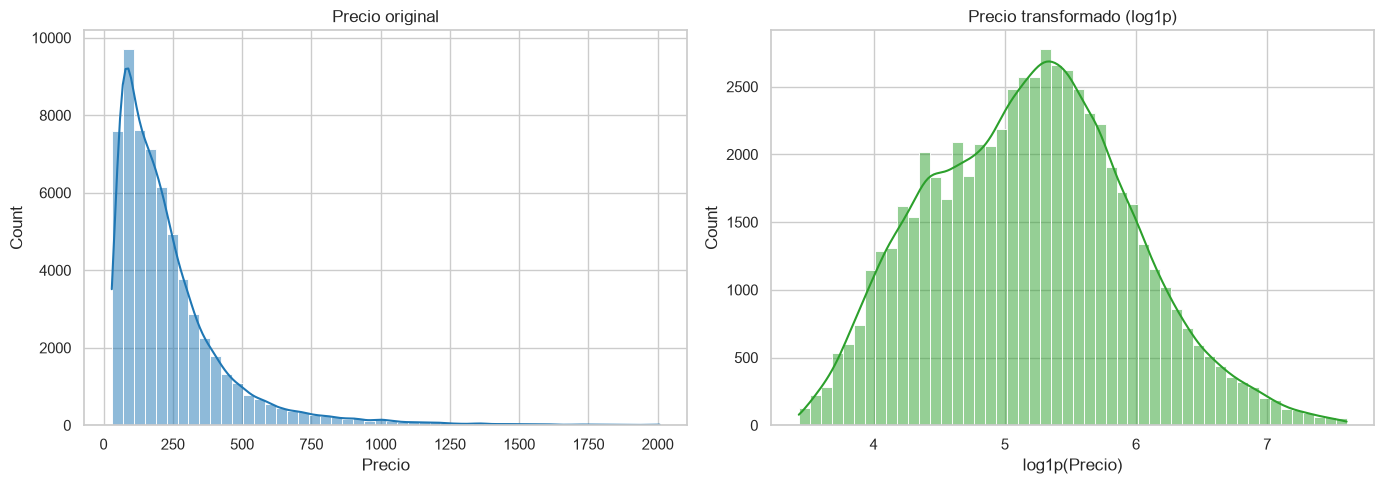

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(precio, kde=True, bins=50, ax=axes[0], color="#1f77b4")
axes[0].set_title("Precio original")
axes[0].set_xlabel("Precio")

sns.histplot(np.log1p(precio), kde=True, bins=50, ax=axes[1], color="#2ca02c")
axes[1].set_title("Precio transformado (log1p)")
axes[1].set_xlabel("log1p(Precio)")

plt.tight_layout()
plt.show()

## 2. Variables categóricas

Balance de clases (`price_range`) y distribución de las principales variables categóricas.

C:\Users\user\AppData\Local\Temp\ipykernel_14480\15857636.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


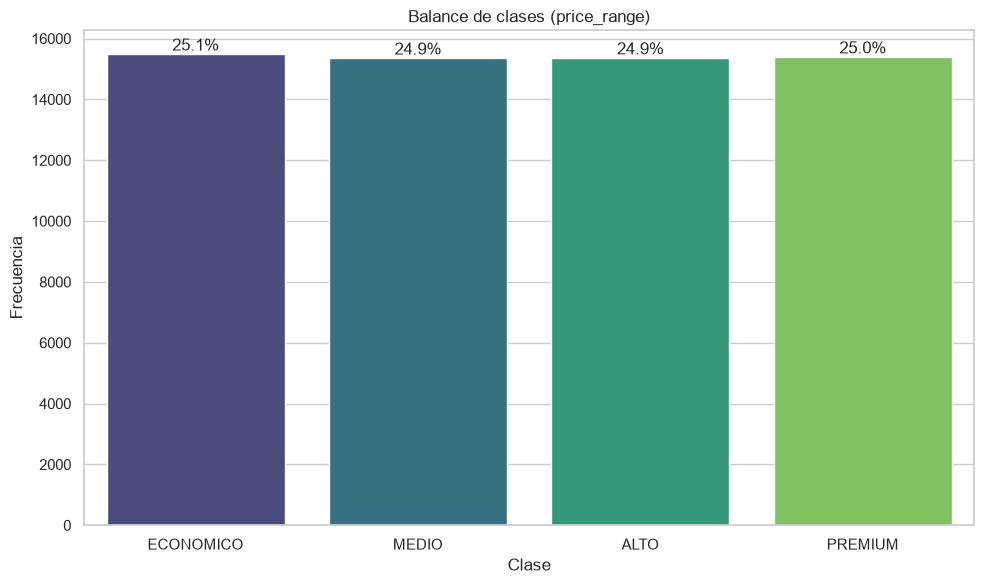

In [4]:
orden_clases = ["ECONOMICO", "MEDIO", "ALTO", "PREMIUM"]

ax = sns.countplot(
    data=df,
    x="price_range",
    order=orden_clases,
    palette="viridis"
)
ax.set_title("Balance de clases (price_range)")
ax.set_xlabel("Clase")
ax.set_ylabel("Frecuencia")

for p in ax.patches:
    pct = 100 * p.get_height() / len(df)
    ax.annotate(f"{pct:.1f}%", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

plt.tight_layout()
plt.show()

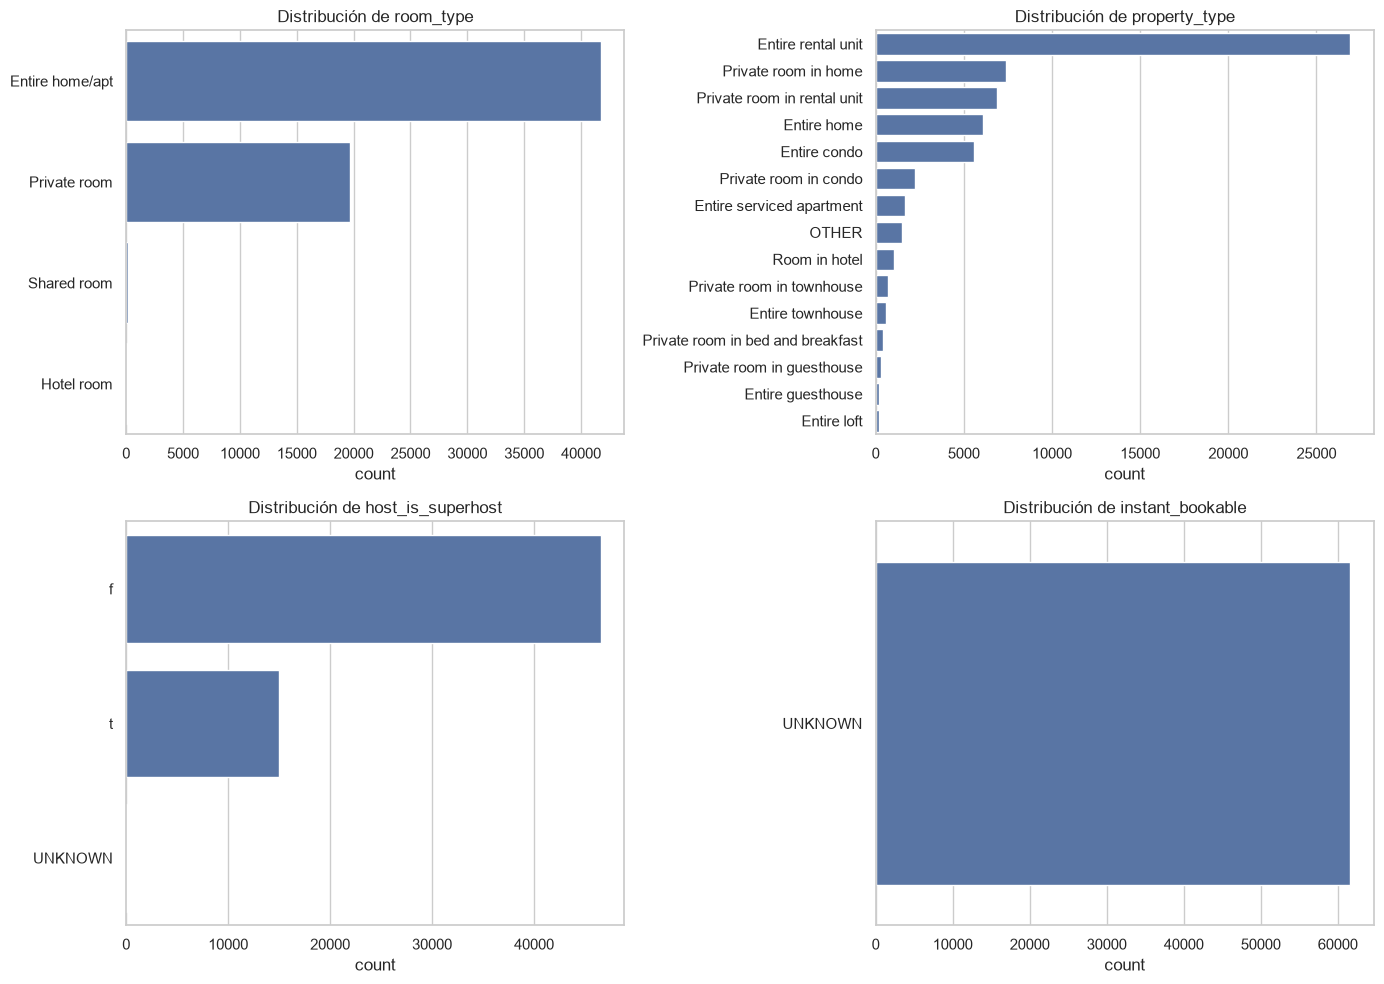

In [5]:
categoricas = ["room_type", "property_type", "host_is_superhost", "instant_bookable"]
categoricas = [c for c in categoricas if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    sns.countplot(data=df, y=col, ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_14480\828868296.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_barrios.values, y=top_barrios.index, palette="crest")


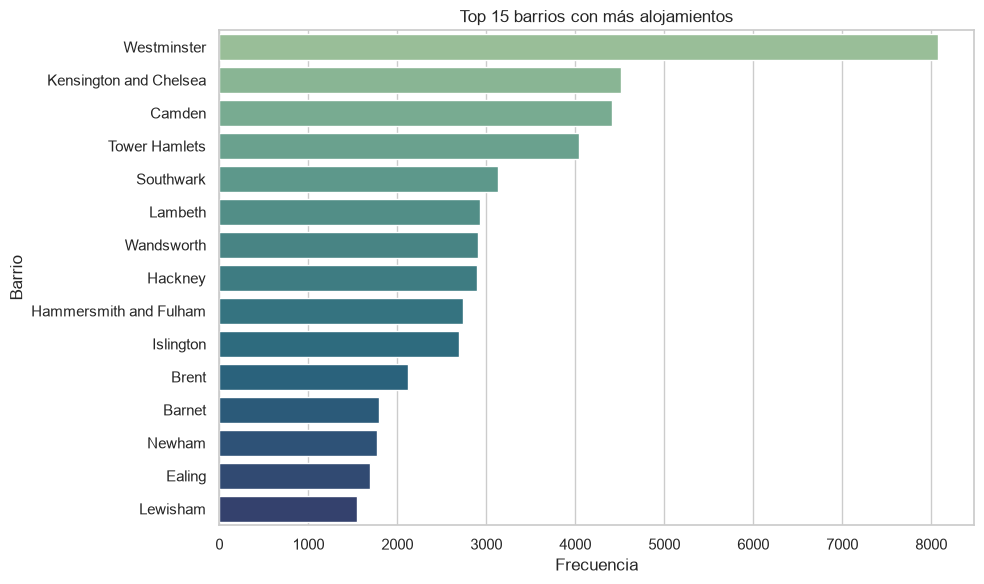

In [6]:
top_barrios = df["neighbourhood_cleansed"].value_counts().head(15)

ax = sns.barplot(x=top_barrios.values, y=top_barrios.index, palette="crest")
ax.set_title("Top 15 barrios con más alojamientos")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("Barrio")
plt.tight_layout()
plt.show()

## 3. Análisis bivariado

Relación entre el precio y las principales variables de tipo y capacidad.

C:\Users\user\AppData\Local\Temp\ipykernel_14480\1781483468.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="room_type", y="price_clean", ax=axes[0], palette="Set2")
C:\Users\user\AppData\Local\Temp\ipykernel_14480\1781483468.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="room_type", y="price_clean", ax=axes[1], palette="Set2")


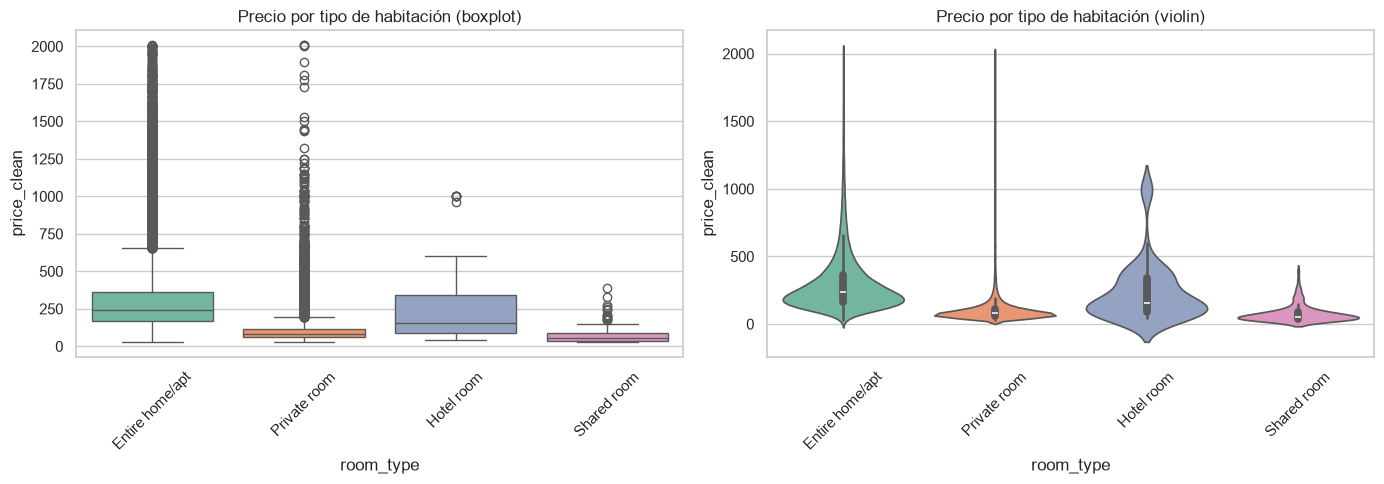

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="room_type", y="price_clean", ax=axes[0], palette="Set2")
axes[0].set_title("Precio por tipo de habitación (boxplot)")
axes[0].tick_params(axis="x", rotation=45)

sns.violinplot(data=df, x="room_type", y="price_clean", ax=axes[1], palette="Set2")
axes[1].set_title("Precio por tipo de habitación (violin)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

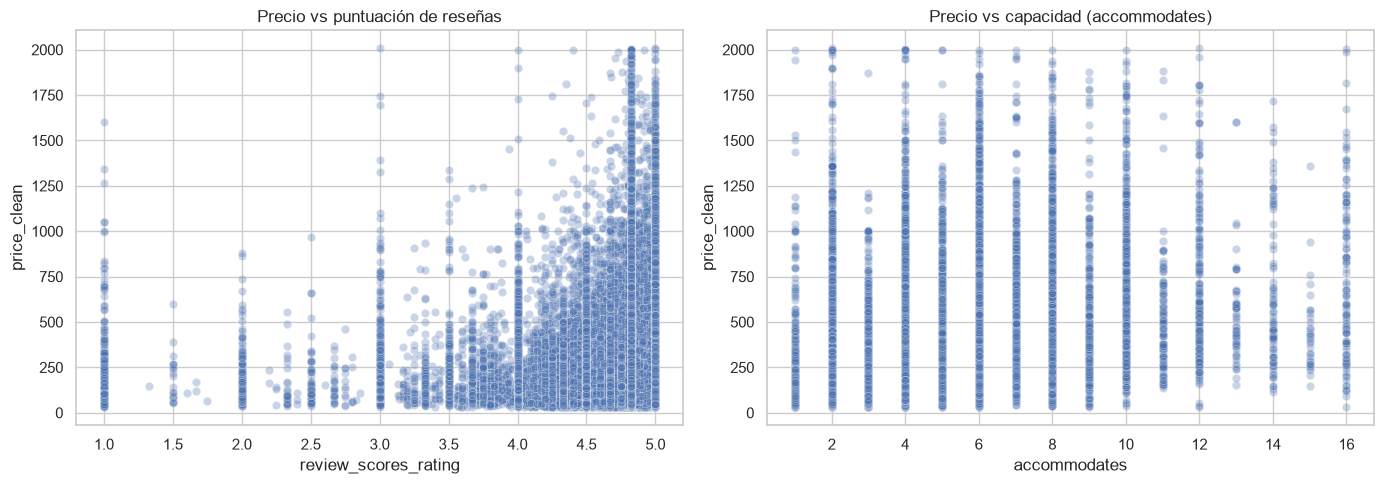

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="review_scores_rating", y="price_clean", alpha=0.3, ax=axes[0])
axes[0].set_title("Precio vs puntuación de reseñas")

sns.scatterplot(data=df, x="accommodates", y="price_clean", alpha=0.3, ax=axes[1])
axes[1].set_title("Precio vs capacidad (accommodates)")

plt.tight_layout()
plt.show()

## 4. Análisis multivariado

Matriz de correlación triangular entre las variables numéricas para detectar multicolinealidad (|r| > 0.85).

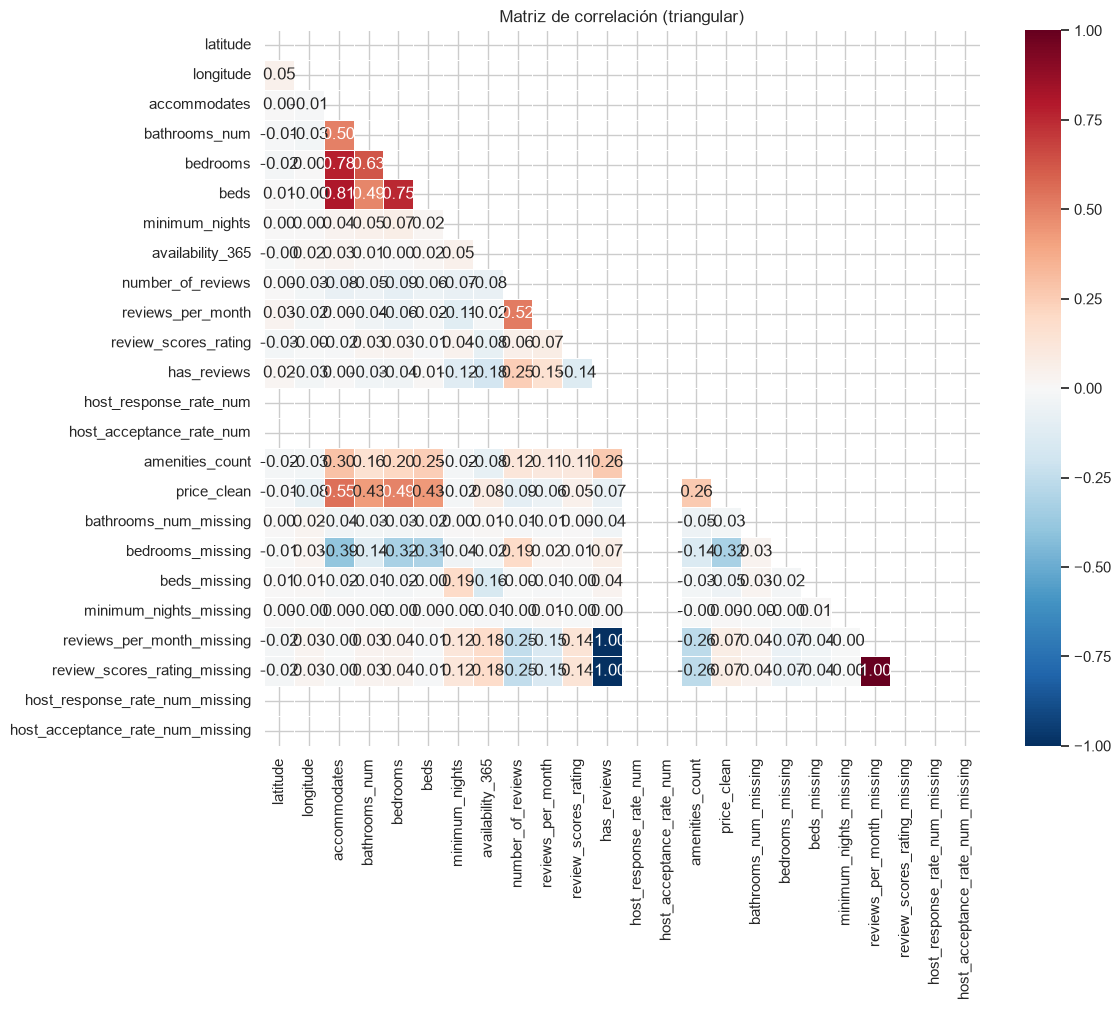

In [ ]:
numericas = df.select_dtypes(include=[np.number]).drop(columns=["id"], errors="ignore")
corr = numericas.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, linewidths=0.5)
plt.title("Matriz de correlación (triangular)")
plt.tight_layout()
plt.show()